In [1]:
import kagglehub
import json

import optuna
from PIL import Image
from pathlib import Path
import numpy as np
import cv2

In [2]:
# Load images

def get_images(download_dataset_flag):
    if download_dataset_flag:
        dataset_path = kagglehub.dataset_download("humansintheloop/teeth-segmentation-on-dental-x-ray-images")
        sources = {k: Path(dataset_path) / f'Teeth Segmentation {k}' for k in ['JSON', 'PNG']}
    else:
        dataset_root = Path(r"")
        sources = {k: dataset_root / f'./Teeth Segmentation {k}' for k in ['JSON', 'PNG']}

    meta = {}
    for p in sources.values():
        meta.update(json.loads((p / 'meta.json').read_text()))

    images = [
        (Image.open(img_path), img_path)
        for p in sources.values()
        for img_path in (p / 'd2' / 'img').glob('*')
    ]

    images2 = [(np.array(image), str(p)) for (image, p) in images[:len(images)//2]]
    return images2

In [3]:
DOWNLOAD_DATASET = False

images_np = get_images(DOWNLOAD_DATASET)

In [4]:
# Get general info about images size

shapes = []
for image_np, _ in images_np:
    shapes.append(image_np.shape)

max_width = np.max(np.array(shapes)[:, 1])
max_height = np.max(np.array(shapes)[:, 0])

In [6]:
# Method changes image size and calculates new polygon positions (but do not save them so we need to either run it every time of rewrite it to save new data

def normalize_image_size(image, image_metadata):
    image_height, image_width = image.shape

    scale_y = max_height / image_height
    scale_x = max_width / image_width

    resized_image = cv2.resize(image, (max_width, max_height))
    image_metadata['size'] = {
        'height': max_height,
        'width': max_width,
    }

    for segment_no in range(len(image_metadata['objects'])):
        for vertex_no in range(len(image_metadata['objects'][segment_no]['points']['exterior'])):
            x = image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][0]
            y = image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][1]
            image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][0] = int(x*scale_x)
            image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][1] = int(y*scale_y)

    return resized_image, image_metadata

In [7]:
import copy

# Method transforms image_number raw images and metadata to resized images and metadata

def adjust_images(images_with_paths, image_number=None):
    normalized_images = []
    images_with_metadata = []
    for image, image_path in images_with_paths[:image_number if image_number else len(images_with_paths)]:
        metadata_filename = image_path.split('\\')[-1] + '.json'
        metadata_path = '\\'.join(image_path.split('\\')[:-2]) + '\\ann\\' + metadata_filename
        with open(metadata_path, 'r') as f:
            image_metadata = json.load(f)
        images_with_metadata.append((image, image_metadata, image_path))
        resized_image, resized_image_metadata = normalize_image_size(image, copy.deepcopy(image_metadata))
        normalized_images.append((resized_image, resized_image_metadata))

    return normalized_images, images_with_metadata

In [8]:
def get_image_names(images_with_paths):
    return [p.split('\\')[-1] for _, p in images_with_paths]

In [9]:
resized_images, original_images = adjust_images(images_np)

In [17]:
idxs = sorted([str(i) for i in range(1,len(resized_images)+1)])

In [18]:
teeth_class_to_teeth_type_map = {}
for i in range(1,33):
    if i in [1,2,3,14,15,16,17,18,19,30,31,32]:
        teeth_class_to_teeth_type_map[i] = 0
    elif i in [4,5,12,13,20,21,28,29]:
        teeth_class_to_teeth_type_map[i] = 1
    elif i in [6,11,22,27]:
        teeth_class_to_teeth_type_map[i] = 2
    elif i in [7,8,9,10,23,24,25,26]:
        teeth_class_to_teeth_type_map[i] = 3

In [23]:
#  Method to separate xrays of children teeth and some corrupted data (multiple contours for teeth of the same class, we discard 64 photos here)

def discard_children_teeth_xrays(one_image_data):
    image, metadata = one_image_data
    xs = []
    ys = []
    teeth_classes = []
    teeth_types = []
    for segment_no in range(len(metadata['objects'])):
        arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
        arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
        teeth_classes.append(int(metadata['objects'][segment_no]['classTitle']))
        teeth_types.append(teeth_class_to_teeth_type_map[teeth_classes[-1]])
        xs.append(arr[:, 0])
        ys.append(arr[:, 1])

    if len(set(teeth_classes)) != len(teeth_classes) != 0:
        return False
    return True

In [24]:
images_adults = []
idxs_adults = []
images_children = []
idxs_children = []
for image_data, image_idx in zip(resized_images, idxs):
    result = discard_children_teeth_xrays(image_data)
    if result:
        images_adults.append(image_data)
        idxs_adults.append(image_idx)
    else:
        images_children.append(image_data)
        idxs_children.append(image_idx)

In [41]:
from matplotlib import pyplot as plt

# Method detects multiple edges on the image, thanks to high clipLimit on CLAHE and very small threshold params on Canny method, then arctan between sobel mask edges in both directions, and try to keep only horizontal edges, for us to see more clearly the jawbone shape
def extract_jaw_directional_edges(image, debug=False):
    clahe = cv2.createCLAHE(clipLimit=15.0, tileGridSize=(4,4))
    enhanced = clahe.apply(image)
    if debug:
        plt.imshow(enhanced, cmap='gray')
        plt.show()
    blurred = cv2.GaussianBlur(enhanced, (3,3), 0)
    edges = cv2.Canny(blurred, threshold1=0, threshold2=20)
    if debug:
        plt.imshow(edges, cmap='gray')
        plt.show()

    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=11)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=11)
    edge_angle = np.arctan2(sobel_y, sobel_x)

    h, w = image.shape
    center_x, center_y = w // 2, h // 2
    filtered_edges = np.zeros_like(edges)

    edge_coords = np.argwhere(edges > 0)

    for y, x in edge_coords:
        dx = x - center_x
        dy = y - center_y

        pixel_angle = np.arctan2(dy, dx)
        gradient_angle = edge_angle[y, x]
        angle_diff = abs(pixel_angle - gradient_angle)
        if angle_diff < np.pi / 2 or angle_diff > 3 * np.pi / 2:
            filtered_edges[y, x] = 255

    if debug:
        plt.imshow(filtered_edges, cmap='gray')
        plt.show()

    return filtered_edges

In [266]:
def find_upper_mandible_border(idx, image, original, debug=False):
    # Method finds horizontal lines without edges in the middle of the "Canny+Sobel" edged images, and for every horizontal line, check its difference to neighbouring (10 px lower) lines, if the difference is high, we set the line as a probable jawbone upper edge, use the line with the lowest position as a final jawbone upper edge
    h, w = image.shape
    image = cv2.GaussianBlur(image, (5,5), 0)
    if debug:
        plt.imshow(image, cmap='gray')
        plt.show()

    margin = int(w * 0.25)
    roi = image[:, margin:-margin]
    if debug:
        plt.imshow(roi, cmap='gray')
        plt.show()

    proj = np.sum(roi, axis=1).astype(np.float32)
    proj = cv2.GaussianBlur(proj.reshape(-1,1), (1,51), 0).flatten()
    search_from = int(h*0.02)
    search_to   = int(h*0.35)

    v=10
    ys = []
    diffs = []
    for y in range(search_from+v, search_to):
        diff = proj[y-v:y].mean() - proj[y:y+v].mean()
        ys.append(y)
        diffs.append(diff)

    diffs = np.array(diffs)
    ys = np.array(ys)
    max_diff = np.max(diffs)
    max_y = ys[np.argmax(diffs)]

    y_to_check = ys[diffs > (2500 if max_diff * 0.4 > 2500 else max_diff*0.4)]

    vis = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    cv2.line(vis, (0, max_y), (w, max_y), (0, 255, 0), 3)

    return vis, y_to_check[-1]

In [72]:
# Find the jawbone on the cropped image, adaptive thresholding, then erosion of the left and right 15% of the image, to separate jawbone from the noise and light on the image, then find contours on the image, and get all that are bigger than some threshold = 30000 of its area, then combine all the chosen edges, create convex hull around them, and its shape is the mask that contains jawbone

def create_bone_mask(image, debug=False):
    denoised = cv2.bilateralFilter(image, 1, 50, 50)
    clahe = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(8,8))
    denoised = clahe.apply(denoised)

    binary = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=1501,
        C=10
    )
    if debug:
        plt.imshow(binary, cmap='gray')
        plt.axis('off')
        plt.show()

    w,h = binary.shape
    part = 0.15
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (23,23))
    binary[:, :int(w*part)] = cv2.morphologyEx(binary[:, :int(w*part)], cv2.MORPH_ERODE, kernel, iterations=6)
    binary[:, -int(w*part):] = cv2.morphologyEx(binary[:, -int(w*part):], cv2.MORPH_ERODE, kernel, iterations=6)

    # if debug:
    #     plt.imshow(binary, cmap='gray')
    #     plt.show()

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return np.ones_like(image) * 255

    jaw_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    jaw_mask_before = np.zeros_like(image)
    max_contour = 30_000
    i=0
    chosen_contours = []
    while cv2.contourArea(jaw_contours[i]) >= max_contour:
        cv2.drawContours(jaw_mask_before, [jaw_contours[i]], -1, 255, -1)
        chosen_contours.append(jaw_contours[i])
        i+=1


    h, w = jaw_mask_before.shape
    combined_points = np.vstack(chosen_contours)
    boundary = cv2.convexHull(combined_points)

    if debug:
        vis = cv2.cvtColor(jaw_mask_before, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(vis, [boundary], -1, (255, 255, 0), 3)
        plt.imshow(vis, cmap='gray')
        plt.axis('off')
        plt.show()

    # if debug:
    #     vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    #     for contour in chosen_contours:
    #         cv2.drawContours(vis, [contour], -1, (0, 255, 0), 2)
    #     cv2.drawContours(vis, [boundary], -1, (255, 255, 0), 3)
    #     plt.imshow(vis, cmap='gray')
    #     plt.show()

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(mask, [boundary], -1, 255, -1)

    if debug:
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
        plt.show()

    return mask

def apply_bone_mask(image, mask):
    # Use mask on the xray image
    return cv2.bitwise_and(image, image, mask=mask)


In [73]:
def update_image_metadata(masked_image, resized_metadata):
    image_height, image_width = masked_image.shape
    metadata, top_y = resized_metadata
    metadata = copy.deepcopy(metadata)
    metadata['size'] = {
        'height': image_height,
        'width': image_width,
    }

    for segment_no in range(len(metadata['objects'])):
        for vertex_no in range(len(metadata['objects'][segment_no]['points']['exterior'])):
            y = metadata['objects'][segment_no]['points']['exterior'][vertex_no][1]
            y -= top_y
            if y < 0:
                y = 0
            if y > image_height-1:
                y = image_height-1
            metadata['objects'][segment_no]['points']['exterior'][vertex_no][1] = y

    return metadata

In [77]:
# Get shape features / descriptors from single contour

def get_contour_features(contour, image):
    features = {'area': cv2.contourArea(contour)}
    perimeter = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)
    features['bbox_width'] = w
    features['bbox_height'] = h
    features['bbox_area'] = w * h
    features['aspect_ratio'] = h / w if w > 0 else 0

    hull = cv2.convexHull(contour)
    hull_perimeter = cv2.arcLength(hull, True)
    features['convexity'] = hull_perimeter / perimeter
    features['circularity'] = (4 * np.pi * features['area']) / (perimeter ** 2)

    if len(contour) >= 5:
        ellipse = cv2.fitEllipse(contour)
        center, axes, angle = ellipse
        major_axis = max(axes)
        minor_axis = min(axes)

        features['ellipse_minor_axis'] = minor_axis
        features['ellipse_eccentricity'] = np.sqrt(1 - (minor_axis/major_axis)**2) if major_axis > 0 else 0
    else:
        return None

    _, radius = cv2.minEnclosingCircle(contour)
    circle_area = np.pi * (radius ** 2)
    features['circle_occupancy'] = features['area'] / circle_area if circle_area > 0 else 0

    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()
    hu_moments_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)

    for i, hu in enumerate(hu_moments_log[:2]):
        features[f'hu_moment_{i+1}'] = hu

    mask = np.zeros(image.shape, dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    tooth_pixels = image[mask == 255]
    features['intensity_mean'] = np.mean(tooth_pixels)

    return features


In [250]:
from collections import defaultdict


def get_teeth_features(masked_image, contours):
    teeth_features = defaultdict(lambda: list())
    no_features_segments = []
    for segment_no in range(len(contours)):
        contour = contours[segment_no]
        contour = contour.reshape(-1, 1, 2)
        segment_features = get_contour_features(contour, masked_image)
        if segment_features:
            for k, v in segment_features.items():
                teeth_features[k].append(v)
        else:
            no_features_segments.append(segment_no)

    return teeth_features, no_features_segments

In [80]:
import pickle

with open('teeth_type_svm.pkl','rb') as file:
    clf = pickle.load(file)
with open('scaler.pkl','rb') as file:
    scaler = pickle.load(file)

In [274]:
def separate_detected_jaws(image, contours, no_features_segments=None):
    tops = []
    centroids = []
    for segment_no in range(len(contours)):
        if no_features_segments is not None and segment_no in no_features_segments:
            continue

        x, y, w, h = cv2.boundingRect(contours[segment_no])
        cy = y + h/2

        tops.append(y)
        centroids.append(cy)

    tops = np.array(tops)
    centroids = np.array(centroids)
    h, w = image.shape

    medium_y1 = np.min(tops) + h*0.33
    mask = centroids > medium_y1
    labels1 = np.zeros_like(centroids, dtype=int)
    meeting_indices = np.where(mask)[0]
    if len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[-16:]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels1[final_indices] = 1
    elif len(centroids) - len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[:16]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels1[final_indices] = 0
    else:
        labels1[mask] = 1

    medium_y2 = np.min(tops) + h*0.225
    mask = tops > medium_y2
    labels2 = np.zeros_like(tops, dtype=int)
    meeting_indices = np.where(mask)[0]
    if len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[-16:]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels2[final_indices] = 1
    elif len(centroids) - len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[:16]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels2[final_indices] = 0
    else:
        labels2[mask] = 1

    upper_teeth = []
    lower_teeth = []

    labels = []

    for i, tooth_contour in enumerate(contours):
        if labels1[i] == labels2[i] == 0:
            upper_teeth.append(tooth_contour)
            labels.append(0)
        elif labels1[i] == labels2[i]:
            lower_teeth.append(tooth_contour)
            labels.append(1)
        else:
            upper_teeth.append(tooth_contour)
            labels.append(0)
    labels = np.array(labels).astype(bool)
    if len(lower_teeth) == 0:
        if np.mean(centroids) > 0.5*h:
            lower_teeth = upper_teeth.copy()
            upper_teeth = []
            labels = ~labels
    return upper_teeth, lower_teeth, labels

In [113]:
with open('upper_jaw_template.json', 'r') as file:
    upper_template = json.load(file)
with open('lower_jaw_template.json', 'r') as file:
    lower_template = json.load(file)

In [252]:
def estimate_jaw_extent(detected_teeth, image, min_jaw_frac=0.225):
    h, w = image.shape

    x_positions = detected_teeth[:, 0]
    leftmost_x = min(x_positions)
    rightmost_x = max(x_positions)

    leftmost_frac = leftmost_x / w
    rightmost_frac = rightmost_x / w
    dist_to_left = leftmost_frac
    dist_to_right = 1 - rightmost_frac

    jawbone_frac = min(min(dist_to_left, dist_to_right), min_jaw_frac)
    return jawbone_frac


def match_teeth_template(detected_teeth, template, image, detected_types, jaw_type='upper', type_penalty_weight=0.00, penalty_power=1, min_jaw_frac=0.225):

    if len(detected_teeth) < 1:
        return [], [], []

    current_teeth = detected_teeth.copy()
    one_jaw_data = []
    for i, contour in enumerate(current_teeth):
        moments = cv2.moments(contour)
        if moments['m00'] != 0:
            cx = moments['m10'] / moments['m00']
            cy = moments['m01'] / moments['m00']
        else:
            x, y, w, h = cv2.boundingRect(contour)
            cx = x + w/2
            cy = y
        one_jaw_data.append(np.array([cx, cy]))
    teeth_numbers = np.arange(0, len(one_jaw_data))
    one_jaw_data = np.array(one_jaw_data)
    detected_types = [dtype for dtype, _ in sorted(zip(detected_types, one_jaw_data), key=lambda pair: pair[1][0])]
    sorted_one_jaw_data = sorted(one_jaw_data, key=lambda a: a[0])
    sorted_one_jaw_data = np.array(sorted_one_jaw_data)
    jawbone_frac = estimate_jaw_extent(sorted_one_jaw_data, image, min_jaw_frac)
    template_positions = sorted([t['mean'][0] for t in template.values()], reverse=False if jaw_type=='upper' else True)

    min_template_position = min(template_positions)
    template_positions = [-min_template_position+tp for tp in template_positions]
    template_positions = np.array(template_positions)
    template_positions /= max(template_positions)
    template_positions *= (1 - 2*jawbone_frac)
    template_positions += jawbone_frac

    x_positions = one_jaw_data[:, 0]
    norm_x_positions = x_positions / image.shape[1]

    template_ids = sorted(template.keys())
    n_template = len(template_ids)
    template_types = [teeth_class_to_teeth_type_map[int(template[tid]['tooth_id'])] for tid in template_ids]

    n_detected = len(detected_teeth)
    cost_matrix = np.zeros((n_detected, n_template))
    for i in range(n_detected):
        detected_arc_pos = norm_x_positions[i]
        for j in range(n_template):
            template_arc_pos = template_positions[j]
            arc_distance = abs(detected_arc_pos - template_arc_pos)
            type_match = detected_types[i] == template_types[j]
            type_penalty = 0.0 if type_match else type_penalty_weight
            cost_matrix[i, j] = (arc_distance + type_penalty)**penalty_power

    from scipy.optimize import linear_sum_assignment
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    assignments = []

    for i, j in zip(row_ind, col_ind):
        assignments.append({
            'detected_idx': teeth_numbers[i],
            'tooth_id': j+1 if jaw_type=='upper' else 17+j,
            'cost': cost_matrix[i, j],
            'position': norm_x_positions[i]
        })

    assigned_ids = set([a['tooth_id'] for a in assignments])
    missing_teeth = [tid for tid in template_ids if tid not in assigned_ids]
    return missing_teeth, assignments, template_positions*image.shape[1]

In [152]:
preprocessed_images_adults = []

for adult_image, adult_image_idx in zip(images_adults, idxs_adults):
    original_img, img_metadata = adult_image
    image_h, image_w = original_img.shape
    original_img = original_img[0:int(image_h*0.9), :]
    edge_img = extract_jaw_directional_edges(original_img, debug=False)
    result_img, top_y_bound = find_upper_mandible_border(adult_image_idx, edge_img, original_img, debug=False)
    cropped_image = original_img[top_y_bound:, :]
    bone_mask = create_bone_mask(cropped_image, debug=False)
    teeth_region = apply_bone_mask(cropped_image, bone_mask)
    masked_metadata = update_image_metadata(teeth_region, (img_metadata, top_y_bound))
    preprocessed_images_adults.append((teeth_region, masked_metadata))

In [168]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, accuracy_score
import preprocessing
from skimage.feature import hog
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import segmentation
import matplotlib.path as matpat
import optuna


class ToothDetector:
    PATCH_SIZE = (32, 64)
    HOG_PARAMS = dict(pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=9)
    COLORS = {
        (True, True): ('lime', 'TP'),
        (True, False): ('orange', 'FN'),
        (False, True): ('purple', 'FP'),
        (False, False): ('blue', 'TN'),
    }

    def __init__(self, segment=segmentation.segment_teeth_watershed, preprocess=preprocessing.preprocess_dental_xray, kernel_shape=(3, 30), svc_kw=None):
        self.segment = segment
        self.preprocess = preprocess
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_shape)
        self.test_teeth = None
        self.pipe = make_pipeline(
            StandardScaler(),
            SVC(**(svc_kw or dict(kernel='rbf', C=3, class_weight={1: 1, 0: 1}, gamma='auto')))
        )

    # ── Image processing ──────────────────────────────────────────────

    def roi(self, image):
        blurred = cv2.GaussianBlur(image, (7, 7), sigmaX=2, sigmaY=2)
        return cv2.erode(self.preprocess(blurred), self.kernel)

    def _segments(self, roi):
        """Yield (pixel_indices, centroid_xy, hog_vector) per valid segment."""
        _, _, markers = self.segment(roi)
        for seg in np.unique(markers):
            if seg <= 1:
                continue
            idx = np.argwhere(markers == seg)
            if np.ptp(idx, axis=0).min() < 16:
                continue
            (r0, c0), (r1, c1) = idx.min(0), idx.max(0)
            patch = cv2.resize(roi[r0:r1, c0:c1], self.PATCH_SIZE)
            centroid = idx.mean(0)[::-1]  # (x, y)
            yield idx, centroid, hog(patch, **self.HOG_PARAMS)

    @staticmethod
    def _match_teeth(centroid, tooth_paths):
        """Check if centroid falls inside any annotated tooth polygon."""
        return any(p.contains_points([centroid]) for p in tooth_paths)


    def gather(self, images, rng):
        """ Gathering data from images """
        all_feats, all_labels, teeth_counts = [], [], []
        for i in rng:
            paths = [matpat.Path(p) for p in segmentation.get_teeth_positions(images[i][1])]
            roi = self.roi(images[i][0])

            for _, centroid, feat in self._segments(roi):
                all_feats.append(feat)
                all_labels.append(self._match_teeth(centroid, paths))

            teeth_counts.append(len(paths))

        return np.array(all_feats), np.array(all_labels), teeth_counts

    def train(self, images, train_rng, test_rng):
        """ Training SVC on given arguments """
        x_tr, y_tr, _ = self.gather(images, train_rng)
        x_te, y_te, self.test_teeth = self.gather(images, test_rng)

        self.pipe.fit(x_tr, y_tr)

        for x, y, title in [(x_tr, y_tr, 'Train'), (x_te, y_te, 'Test')]:
            ConfusionMatrixDisplay.from_estimator(self.pipe, x, y)
            plt.title(title)
            plt.show()

        preds = self.pipe.predict(x_te)
        tp = np.sum(y_te & preds.astype(bool))
        print(f'Avg % teeth detected: {tp / sum(self.test_teeth) * 100:.2f}%')

    def predict_teeth(self, image):
        """Return (N, 2) array of centroids for segments classified as teeth."""
        roi = self.roi(image)
        centroids, feats = zip(*[(c, h) for _, c, h in self._segments(roi)]) or ([], [])

        if not feats:
            return np.empty((0, 2))

        mask = self.pipe.predict(np.array(feats)).astype(bool)
        return np.array(centroids)[mask]

    def visualize(self, images, rng):
        # Wizualizacja klasyfikacji
        for i in rng:
            roi = self.roi(images[i, 0])
            paths = [matpat.Path(p) for p in segmentation.get_teeth_positions(images[i, 1])]
            segs = list(self._segments(roi))
            if not segs:
                continue

            idxs, cents, feats = zip(*segs)
            preds = self.pipe.predict(np.array(feats)).astype(bool)
            truths = [self._match_teeth(c, paths) for c in cents]

            plt.figure(figsize=(15, 7))
            plt.imshow(roi)

            seen = set()
            for idx, truth, pred in zip(idxs, truths, preds):
                color, label = self.COLORS[(truth, pred)]
                plt.scatter(idx[:, 1], idx[:, 0], s=0.5, c=color,
                            label=label if color not in seen else None)
                seen.add(color)

            tp = sum(t and p for t, p in zip(truths, preds))
            plt.title(f'{tp}/{len(paths)} teeth ({tp / len(paths) * 100:.0f}%)')
            plt.axis('off')
            plt.legend(markerscale=5)
            plt.show()


# Precompute segments once since image params are fixed
detector = ToothDetector(
    segment=lambda img: segmentation.segment_teeth_watershed(img, threshold=0.1)
)
cached_train = detector.gather(preprocessed_images_adults, range(50))
cached_test = detector.gather(preprocessed_images_adults, range(200, 240))

def objective(trial):
    x_tr, y_tr, _ = cached_train
    x_te, y_te, _ = cached_test

    C = trial.suggest_float('C', 0.1, 50, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 0.01, log=True)
    tooth_weight = trial.suggest_float('tooth_weight', 1.0, 5.0)

    pipe = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=C, gamma=gamma, class_weight={1: tooth_weight, 0: 1})
    )
    pipe.fit(x_tr, y_tr)
    preds = pipe.predict(x_te)
    return f1_score(y_te, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=120, n_jobs=-1)

print(f'Best params: {study.best_params}')
print(f'Best F1: {study.best_value:.4f}')

[I 2026-02-10 23:02:45,201] A new study created in memory with name: no-name-e6ceb598-6d11-47c0-af32-e9f5dd99dd9b
[I 2026-02-10 23:02:54,287] Trial 2 finished with value: 0.7731343283582089 and parameters: {'C': 1.8432187807843154, 'gamma': 0.0001170429779377521, 'tooth_weight': 2.385622569430292}. Best is trial 2 with value: 0.7731343283582089.
[I 2026-02-10 23:02:55,420] Trial 6 finished with value: 0.7774122807017544 and parameters: {'C': 14.751715494396523, 'gamma': 0.00013230343510658662, 'tooth_weight': 4.145080008280997}. Best is trial 6 with value: 0.7774122807017544.
[I 2026-02-10 23:02:55,520] Trial 5 finished with value: 0.737943585077343 and parameters: {'C': 0.1058578175170667, 'gamma': 0.0003875102384200012, 'tooth_weight': 2.4840009609031757}. Best is trial 6 with value: 0.7774122807017544.
[I 2026-02-10 23:02:56,007] Trial 7 finished with value: 0.7729230769230769 and parameters: {'C': 1.2685802351295696, 'gamma': 0.0014882022861042695, 'tooth_weight': 1.145439983917635

Best params: {'C': 2.1245874863282, 'gamma': 0.0005116944444073716, 'tooth_weight': 2.3355958071716665}
Best F1: 0.7971


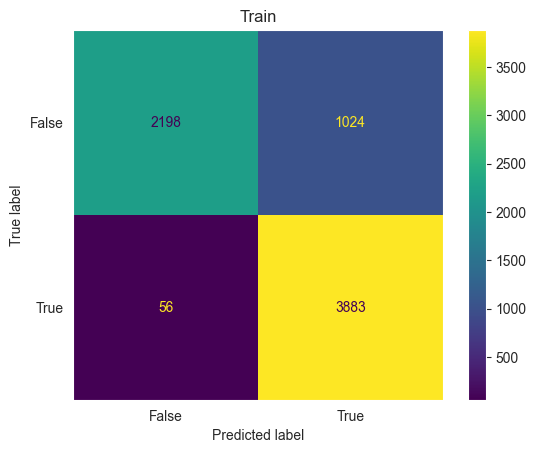

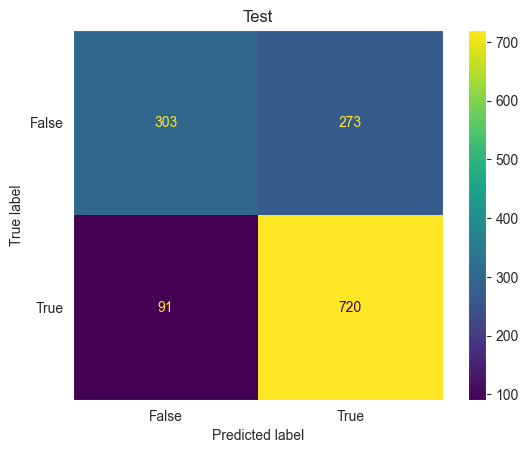

Avg % teeth detected: 68.64%


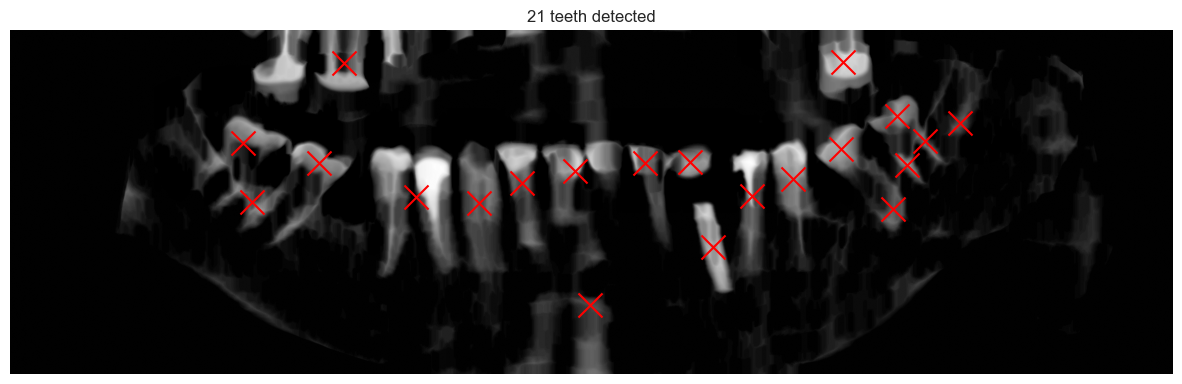

In [170]:
best = study.best_params

detector = ToothDetector(
    segment=lambda img: segmentation.segment_teeth_watershed(img, threshold=0.1),
    svc_kw=dict(kernel='rbf', C=best['C'], gamma=best['gamma'],
                class_weight={1: best['tooth_weight'], 0: 1})
)

# ten drugi range ma bardzo duzy wplyw na dlugosc treningu
detector.train(preprocessed_images_adults, range(200), range(200, 240))

detector_centroids = detector.predict_teeth(preprocessed_images_adults[300][0])

detector_image = detector.roi(preprocessed_images_adults[300][0])
plt.figure(figsize=(15, 7))
plt.imshow(detector_image, cmap='gray')
plt.scatter(detector_centroids[:, 0], detector_centroids[:, 1], c='red', s=300, marker='x')
plt.title(f'{len(detector_centroids)} teeth detected')
plt.axis('off')
plt.show()

In [208]:
def filter_obvious_noise(contour):
    image_area = 2045*500

    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if area == 0 or perimeter == 0:
        return 'zero_area'

    x, y, w_box, h_box = cv2.boundingRect(contour)
    min_area = image_area * 0.004
    max_area = image_area * 0.033

    if area < min_area:
        return 'too_small'

    if area > max_area:
        return 'too_large'

    aspect_ratio = h_box / w_box if w_box > 0 else 0

    if aspect_ratio < 0.2 or aspect_ratio > 8.0:
        return 'wrong_aspect'

    compactness = (perimeter ** 2) / area if area > 0 else 999

    if compactness > 75:
        return 'irregular'

    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    if solidity < 0.3:
        return 'fragmented'

    return None

In [209]:
def check_gt_contour_against_noise(one_masked_image_data, image_idx):
    masked_image, metadata = one_masked_image_data
    teeth_classes = []
    dxs = []
    dys = []
    xs = []
    ys = []
    for segment_no in range(len(metadata['objects'])):
        arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
        arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
        teeth_classes.append(int(metadata['objects'][segment_no]['classTitle']))
        teeth_contour = np.stack([arr[:, 0], arr[:, 1]], axis=1)
        teeth_contour = teeth_contour.reshape(-1, 1, 2)
        result = filter_obvious_noise(teeth_contour)
        if result:
            print(result)
            dxs.append(arr[:, 0])
            dys.append(arr[:, 1])
        else:
            xs.append(arr[:, 0])
            ys.append(arr[:, 1])

    if len(dxs) > 0:
        plt.imshow(masked_image, cmap='gray')
        plt.title(f'Image {image_idx}')
        for x, y in zip(xs, ys):
            plt.plot(x, y, color='green')
        for x, y in zip(dxs, dys):
            plt.plot(x, y, color='red')
        plt.axis('off')

        plt.show()
#
# for masked_image_data, idx in zip(images_adults, idxs_adults):
#     check_gt_contour_against_noise(masked_image_data, idx)


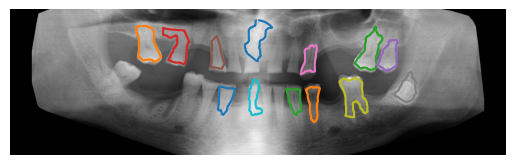

21 13


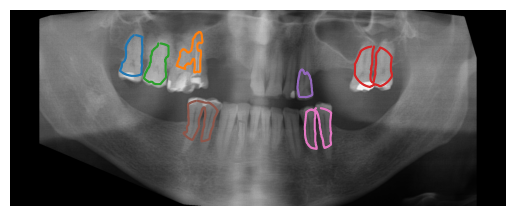

16 8


In [264]:
from importlib import reload
reload(segmentation)

from segmentation import segment_with_mean_shift

for i in range(0, 2):
    preprocessed = preprocessed_images_adults[i][0]
    centroids_array = detector.predict_teeth(preprocessed)

    detector_image = detector.roi(preprocessed_images_adults[i][0])
    centroids_dict = {i: tuple(c) for i, c in enumerate(centroids_array)}
    detector_contours, _ = segment_with_mean_shift(detector_image, centroids_dict, sp=12, sr=30, debug=False)
    plt.imshow(preprocessed, cmap='gray')
    filtered_contours = []
    for detector_contour in detector_contours.values():
        if filter_obvious_noise(detector_contour) is not None:
            continue
        detector_contour = detector_contour.reshape(-1, 2)
        xs = detector_contour[:, 0]
        ys = detector_contour[:, 1]
        plt.plot(xs, ys)
        filtered_contours.append(detector_contour)
    plt.axis('off')

    plt.show()
    print(len(detector_contours), len(filtered_contours))


In [249]:
def prepare_image_teeth_classes(metadata):
    teeth_classes = []
    teeth_types = []
    for segment_no in range(len(metadata['objects'])):
        teeth_classes.append(int(metadata['objects'][segment_no]['classTitle']))
        teeth_types.append(teeth_class_to_teeth_type_map[teeth_classes[-1]])

    return teeth_types, teeth_classes

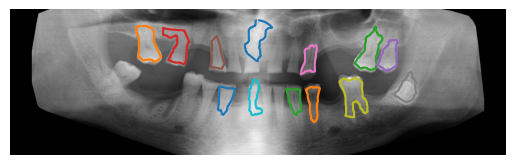

Found teeth: [np.int64(8), np.int64(1), np.int64(15), np.int64(4), np.int64(16), np.int64(6), np.int64(11), np.int64(17), np.int64(19), np.int64(25), np.int64(26), np.int64(21), np.int64(22)]
Ground truth: [8, 9, 10, 11, 7, 6, 4, 2, 15, 16, 17, 19, 21, 22, 23, 24, 25, 27, 28, 29, 32]


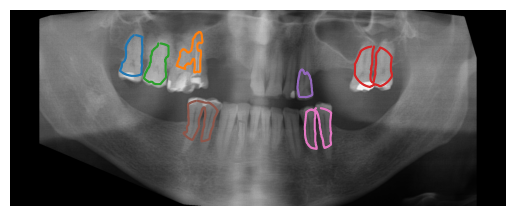

Found teeth: [np.int64(1), np.int64(5), np.int64(3), np.int64(15), np.int64(11), np.int64(29), np.int64(20), np.int64(26)]
Ground truth: [1, 2, 3, 4, 8, 9, 10, 11, 15, 16, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29]


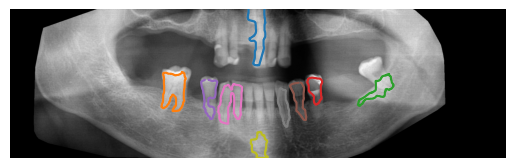

Found teeth: [np.int64(8), np.int64(30), np.int64(17), np.int64(21), np.int64(28), np.int64(22), np.int64(26), np.int64(23), np.int64(25)]
Ground truth: [6, 7, 9, 10, 11, 17, 20, 21, 22, 23, 24, 25, 26, 28, 29, 31]


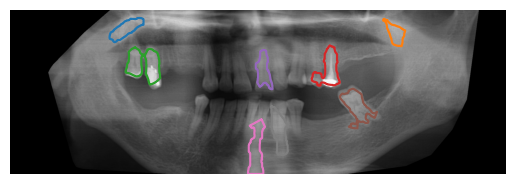

Found teeth: [np.int64(1), np.int64(16), np.int64(3), np.int64(12), np.int64(9), np.int64(19), np.int64(25), np.int64(23)]
Ground truth: [8, 9, 10, 11, 12, 13, 7, 6, 1, 2, 24, 25, 26, 27, 28, 23, 22, 21, 19]


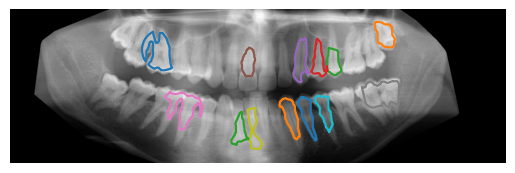

Found teeth: [np.int64(3), np.int64(16), np.int64(13), np.int64(12), np.int64(11), np.int64(8), np.int64(30), np.int64(17), np.int64(25), np.int64(20), np.int64(21), np.int64(23), np.int64(26)]
Ground truth: [8, 9, 24, 25, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 32]


In [275]:
import pandas as pd
reload(segmentation)

for adult_image, adult_image_idx in zip(preprocessed_images_adults[:5], idxs_adults):
    teeth_region, masked_metadata = adult_image

    centroids_array = detector.predict_teeth(teeth_region)

    detector_image = detector.roi(teeth_region)
    centroids_dict = {i: tuple(c) for i, c in enumerate(centroids_array)}
    detector_contours, _ = segment_with_mean_shift(detector_image, centroids_dict, sp=12, sr=30, debug=False)

    plt.imshow(teeth_region, cmap='gray')
    filtered_contours = []
    for detector_contour in detector_contours.values():
        if filter_obvious_noise(detector_contour) is not None:
            continue
        detector_contour = detector_contour.reshape(-1, 2)
        xs = detector_contour[:, 0]
        ys = detector_contour[:, 1]
        plt.plot(xs, ys)
        filtered_contours.append(detector_contour)
    plt.axis('off')
    plt.show()

    filtered_contours = []
    for detector_contour in detector_contours.values():
        if filter_obvious_noise(detector_contour) is not None:
            continue
        filtered_contours.append(detector_contour)

    one_image_features, no_features_contours = get_teeth_features(teeth_region, filtered_contours)
    image_teeth_types, image_teeth_classes = prepare_image_teeth_classes(masked_metadata)

    image_features = defaultdict(lambda: list())
    for key,value in one_image_features.items():
        image_features[key].extend(value)
    df = pd.DataFrame(image_features)
    df_np = df.to_numpy()
    if len(df_np) == 0:
        continue
    df_np = scaler.transform(df_np)
    pred_types = clf.predict(df_np)
    upper_detected, lower_detected, labels_by_jaw = separate_detected_jaws(teeth_region, filtered_contours,no_features_contours)

    upper_pred = pred_types[~labels_by_jaw]
    lower_pred = pred_types[labels_by_jaw]

    # image_teeth_classes = np.array(image_teeth_classes)
    # upper_classes = image_teeth_classes[~labels_by_jaw]
    # lower_classes = image_teeth_classes[labels_by_jaw]
    missed_upper, upper_assignments, upper_template_positions = match_teeth_template(upper_detected, upper_template, teeth_region, upper_pred, 'upper', 0.02, 3, 0.25)
    missed_lower, lower_assignments, lower_template_positions = match_teeth_template(lower_detected, lower_template, teeth_region, lower_pred,'lower', 0.02, 3, 0.25)

    predictions = []
    ground_truth = image_teeth_classes
    # plt.imshow(teeth_region, cmap='gray')
    for aligned_pair in upper_assignments:
        # final_tooth_contour = upper_detected[aligned_pair['detected_idx']]
        # final_moments = cv2.moments(final_tooth_contour)
        # final_cx = final_moments['m10'] / final_moments['m00']
        # final_cy = final_moments['m01'] / final_moments['m00']
        # final_tooth_contour = final_tooth_contour.reshape(-1, 2)
        pred_id = aligned_pair['tooth_id']
        # real_id = upper_classes[aligned_pair['detected_idx']]
        predictions.append(pred_id)
        # contour_color = 'red' if pred_id != real_id else 'green'
        # plt.plot(final_tooth_contour[:, 0], final_tooth_contour[:, 1], color=contour_color)
        # plt.text(final_cx, final_cy, f'{pred_id}\n{real_id}', ha='center', va='center', fontsize=8, fontweight='bold')
    for aligned_pair in lower_assignments:
        # final_tooth_contour = lower_detected[aligned_pair['detected_idx']]
        # final_moments = cv2.moments(final_tooth_contour)
        # final_cx = final_moments['m10'] / final_moments['m00']
        # final_cy = final_moments['m01'] / final_moments['m00']
        # final_tooth_contour = final_tooth_contour.reshape(-1, 2)
        pred_id = aligned_pair['tooth_id']
        # real_id = lower_classes[aligned_pair['detected_idx']]
        predictions.append(pred_id)
        # ground_truth.append(real_id)
        # contour_color = 'red' if pred_id != real_id else 'green'
        # plt.plot(final_tooth_contour[:, 0], final_tooth_contour[:, 1], color=contour_color)
        # plt.text(final_cx, final_cy, f'{pred_id}\n{real_id}', ha='center', va='center', fontsize=8, fontweight='bold')

    print(f'Found teeth: {predictions}')
    print(f'Ground truth: {ground_truth}')
    # plt.axis('off')
    # plt.show()
